In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
import logging

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.FileHandler("eda_decomposition.log"), logging.StreamHandler()]
)
logger = logging.getLogger(__name__)

# Set matplotlib to save figures with absolute path
current_dir = os.getcwd()
if "notebooks" in os.path.basename(current_dir):
    project_root = os.path.dirname(current_dir)  # Go up one level from notebooks/ to sales-forecasting/
else:
    project_root = current_dir  # Already in project root
output_dir = os.path.join(project_root, "reports", "figures", "subcategories")
os.makedirs(output_dir, exist_ok=True)
logger.info(f"Output directory set to: {output_dir}")

2025-06-03 11:14:30,138 - INFO - Output directory set to: c:\Users\sebas\Documents\Data_Science\Portfolio\Data-Science-Portfolio\08_Time_Series_Projects\Time_Series_sktime\sales-forecasting\reports\figures\subcategories


In [9]:
def perform_adf_test(series: pd.Series, subcategory: str) -> None:
    """Perform Augmented Dickey-Fuller test for stationarity."""
    result = adfuller(series.dropna())
    logger.info(f"ADF Test for {subcategory}: p-value = {result[1]:.4f}")
    print(f"ADF Test for {subcategory}: p-value = {result[1]:.4f}")
    if result[1] < 0.05:
        print("Result: Stationary (reject null hypothesis)")
    else:
        print("Result: Non-stationary (fail to reject null hypothesis)")

def perform_kpss_test(series: pd.Series, subcategory: str) -> None:
    """Perform KPSS test for stationarity."""
    result = kpss(series.dropna(), regression="c")
    logger.info(f"KPSS Test for {subcategory}: p-value = {result[1]:.4f}")
    print(f"KPSS Test for {subcategory}: p-value = {result[1]:.4f}")
    if result[1] < 0.05:
        print("Result: Non-stationary (reject null hypothesis)")
    else:
        print("Result: Stationary (fail to reject null hypothesis)")

def plot_seasonal_decomposition(result, subcategory: str) -> None:
    """Plot and save seasonal decomposition components."""
    plt.figure(figsize=(12, 8))
    plt.subplot(4, 1, 1)
    plt.plot(result.observed)
    plt.title(f"Observed - {subcategory}")
    plt.subplot(4, 1, 2)
    plt.plot(result.trend)
    plt.title("Trend")
    plt.subplot(4, 1, 3)
    plt.plot(result.seasonal)
    plt.title("Seasonal")
    plt.subplot(4, 1, 4)
    plt.plot(result.resid)
    plt.title("Residuals")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"decomposition_{subcategory}.png"))
    plt.show()
    plt.close()

2025-06-03 11:21:56,219 - INFO - Processing file: ../data/processed/subcategories\subcategory_0.csv
2025-06-03 11:21:56,231 - INFO - Performing seasonal decomposition for Accessories


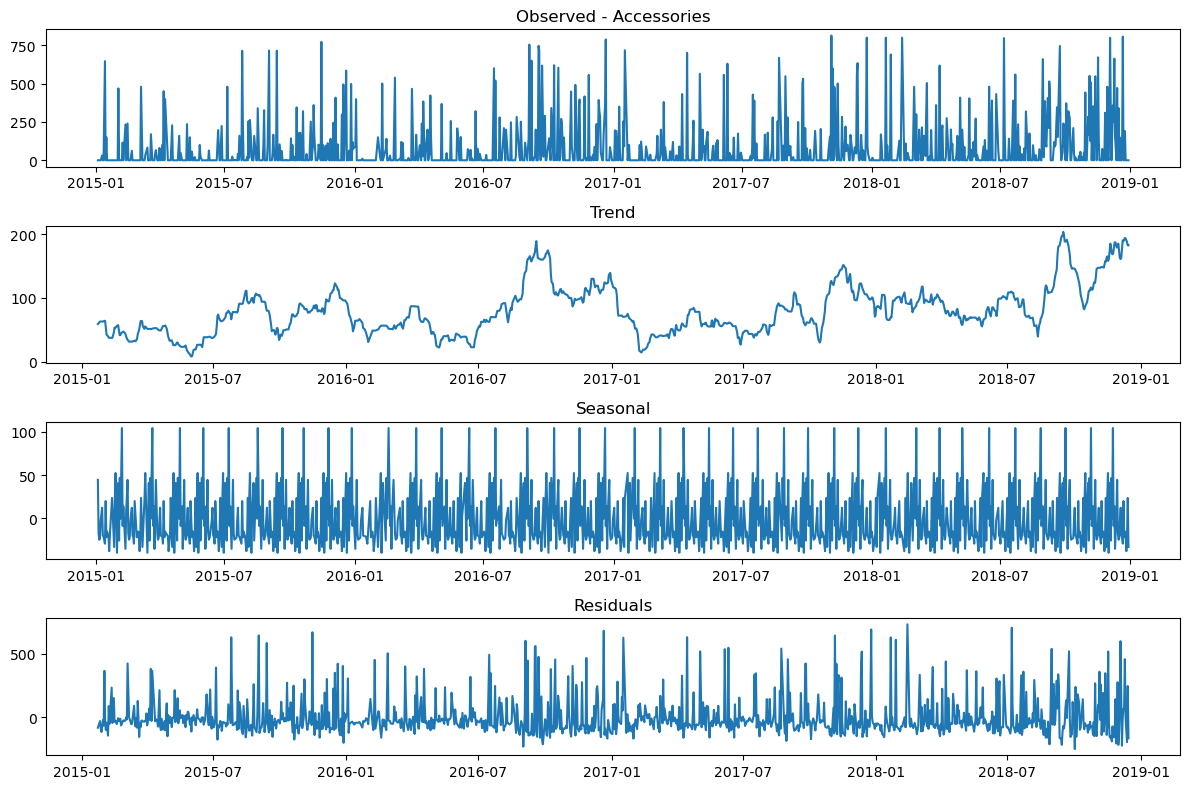

2025-06-03 11:22:04,697 - INFO - Performing ADF test for Accessories
2025-06-03 11:22:05,230 - INFO - ADF Test for Accessories: p-value = 0.0000
2025-06-03 11:22:05,237 - INFO - Performing KPSS test for Accessories
C:\Users\sebas\AppData\Local\Temp\ipykernel_21060\869537997.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression="c")
2025-06-03 11:22:05,241 - INFO - KPSS Test for Accessories: p-value = 0.0100


ADF Test for Accessories: p-value = 0.0000
Result: Stationary (reject null hypothesis)
KPSS Test for Accessories: p-value = 0.0100
Result: Non-stationary (reject null hypothesis)


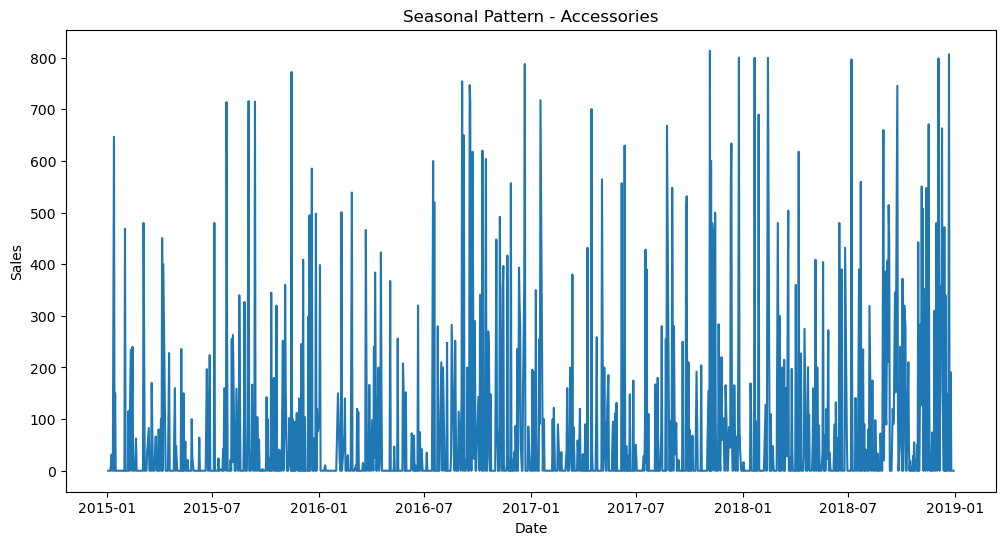

2025-06-03 11:22:07,203 - INFO - Processing file: ../data/processed/subcategories\subcategory_1.csv
2025-06-03 11:22:07,375 - INFO - Performing seasonal decomposition for Appliances


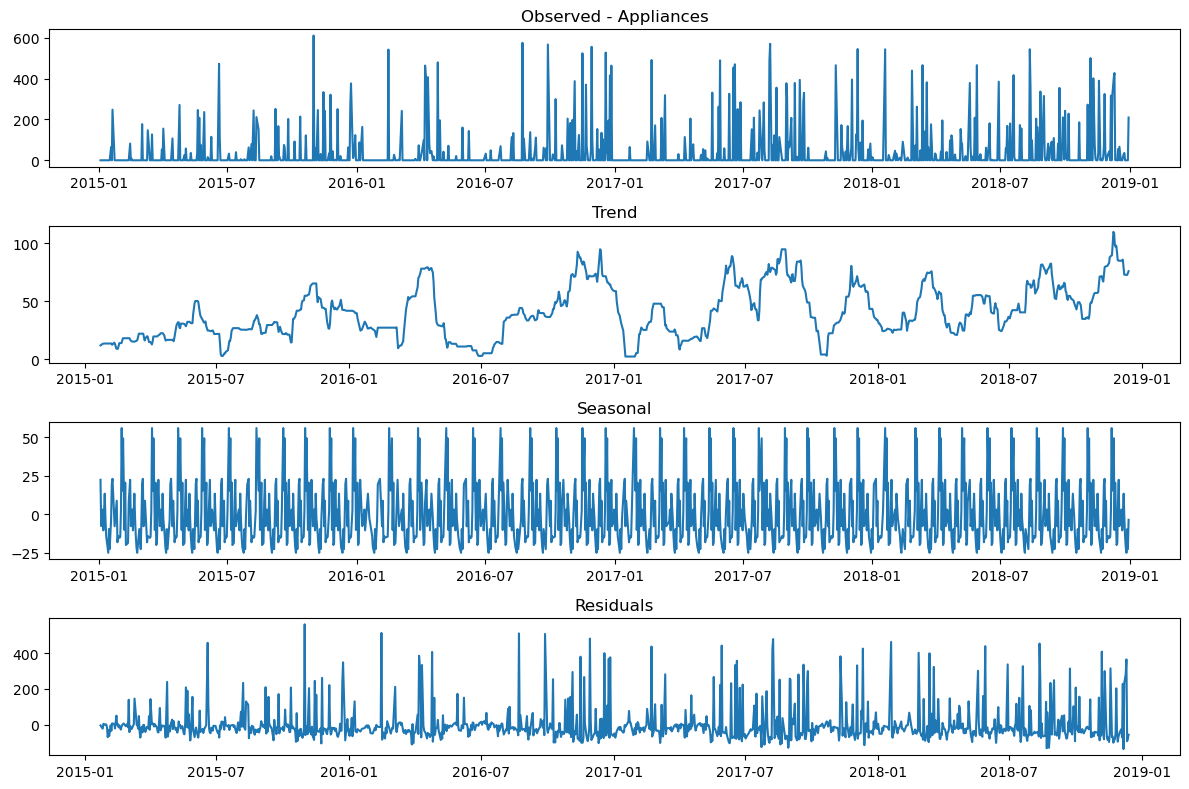

2025-06-03 11:22:14,062 - INFO - Performing ADF test for Appliances
2025-06-03 11:22:14,492 - INFO - ADF Test for Appliances: p-value = 0.0000
2025-06-03 11:22:14,495 - INFO - Performing KPSS test for Appliances
C:\Users\sebas\AppData\Local\Temp\ipykernel_21060\869537997.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression="c")
2025-06-03 11:22:14,501 - INFO - KPSS Test for Appliances: p-value = 0.0100


ADF Test for Appliances: p-value = 0.0000
Result: Stationary (reject null hypothesis)
KPSS Test for Appliances: p-value = 0.0100
Result: Non-stationary (reject null hypothesis)


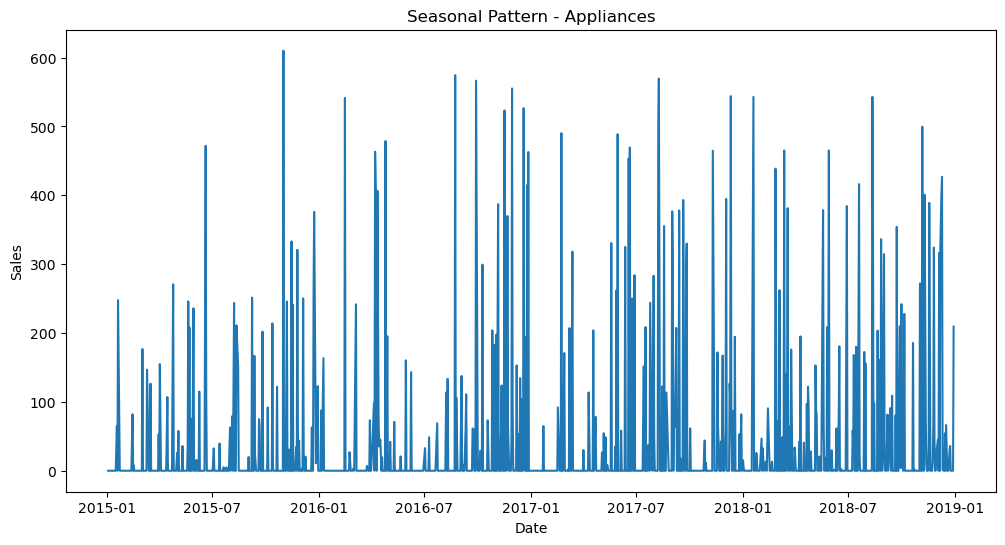

2025-06-03 11:22:15,820 - INFO - Processing file: ../data/processed/subcategories\subcategory_10.csv
2025-06-03 11:22:15,975 - INFO - Performing seasonal decomposition for Labels


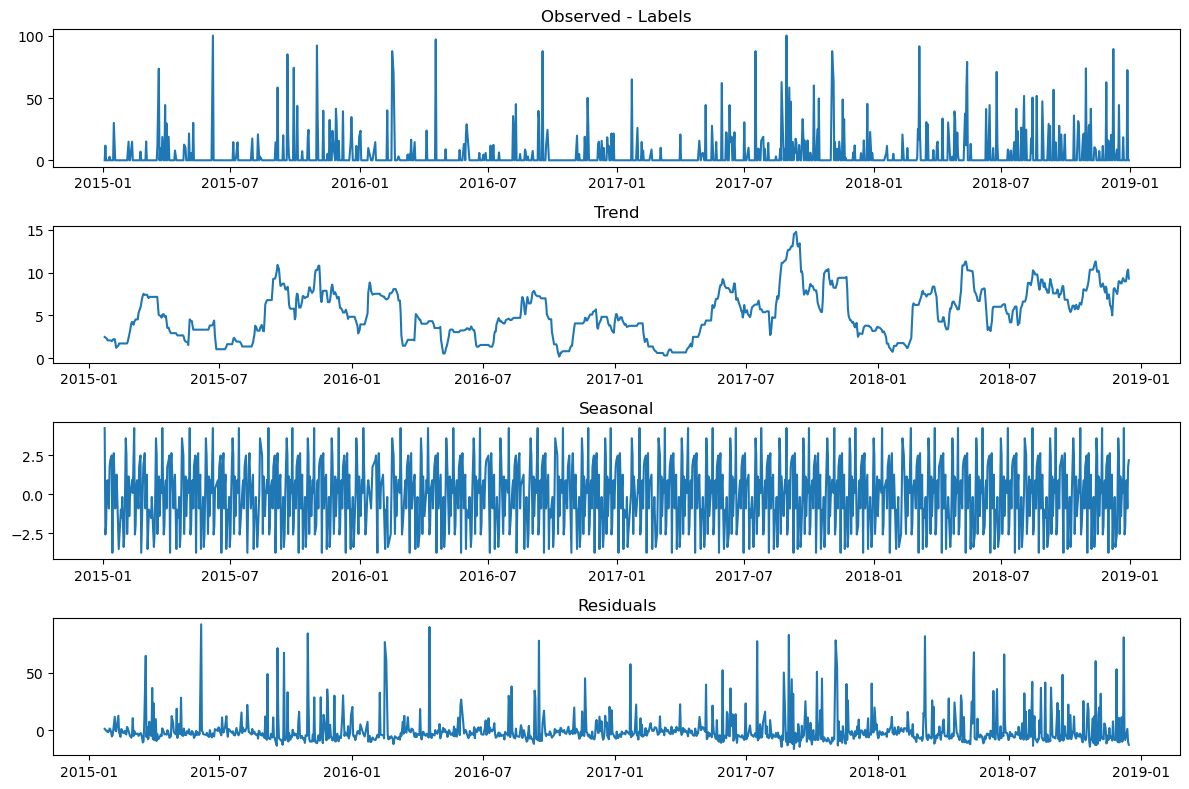

2025-06-03 11:22:24,259 - INFO - Performing ADF test for Labels
2025-06-03 11:22:24,983 - INFO - ADF Test for Labels: p-value = 0.0000
2025-06-03 11:22:24,985 - INFO - Performing KPSS test for Labels
C:\Users\sebas\AppData\Local\Temp\ipykernel_21060\869537997.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression="c")
2025-06-03 11:22:24,990 - INFO - KPSS Test for Labels: p-value = 0.0100


ADF Test for Labels: p-value = 0.0000
Result: Stationary (reject null hypothesis)
KPSS Test for Labels: p-value = 0.0100
Result: Non-stationary (reject null hypothesis)


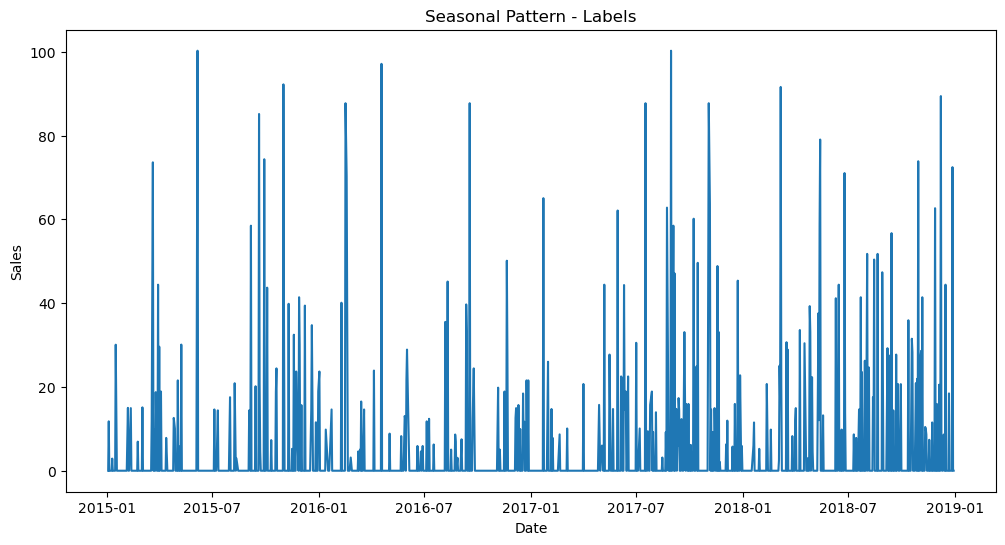

2025-06-03 11:22:26,776 - INFO - Processing file: ../data/processed/subcategories\subcategory_11.csv
2025-06-03 11:22:26,822 - INFO - Performing seasonal decomposition for Machines


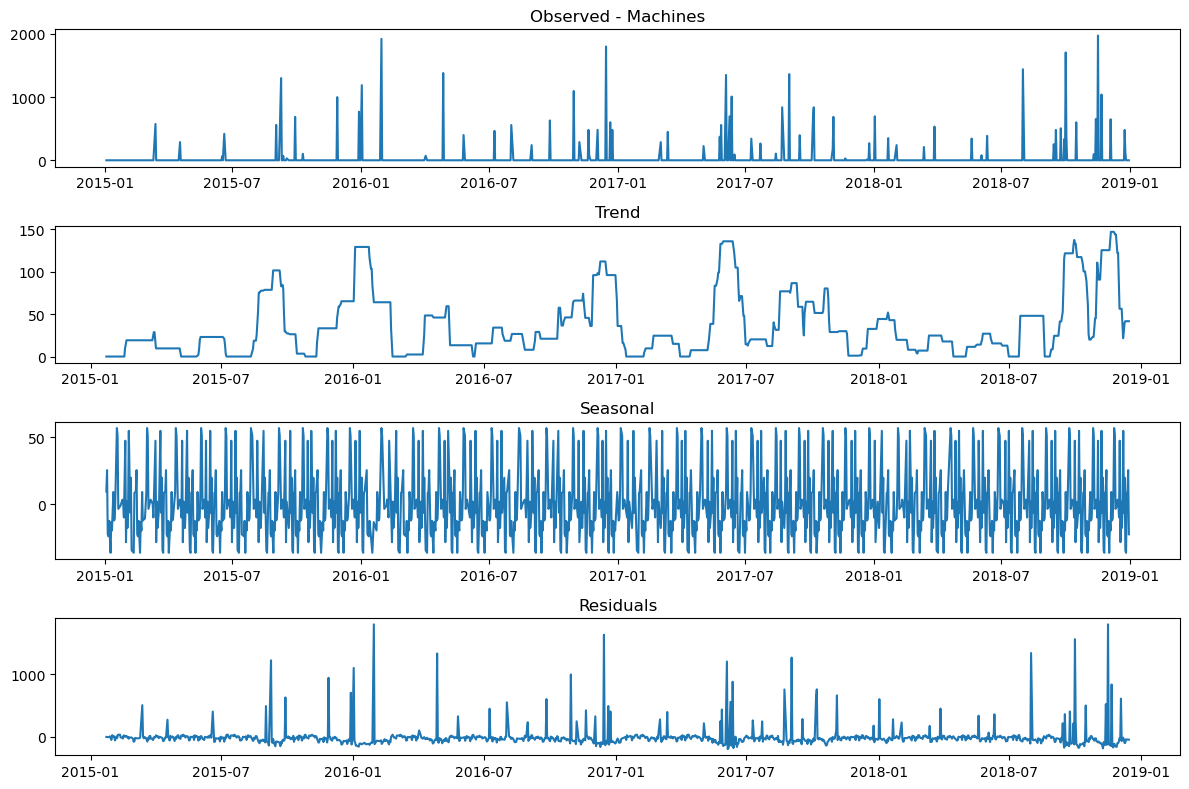

2025-06-03 11:22:32,950 - INFO - Performing ADF test for Machines
2025-06-03 11:22:33,137 - INFO - ADF Test for Machines: p-value = 0.0000
2025-06-03 11:22:33,139 - INFO - Performing KPSS test for Machines
C:\Users\sebas\AppData\Local\Temp\ipykernel_21060\869537997.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression="c")
2025-06-03 11:22:33,155 - INFO - KPSS Test for Machines: p-value = 0.1000


ADF Test for Machines: p-value = 0.0000
Result: Stationary (reject null hypothesis)
KPSS Test for Machines: p-value = 0.1000
Result: Stationary (fail to reject null hypothesis)


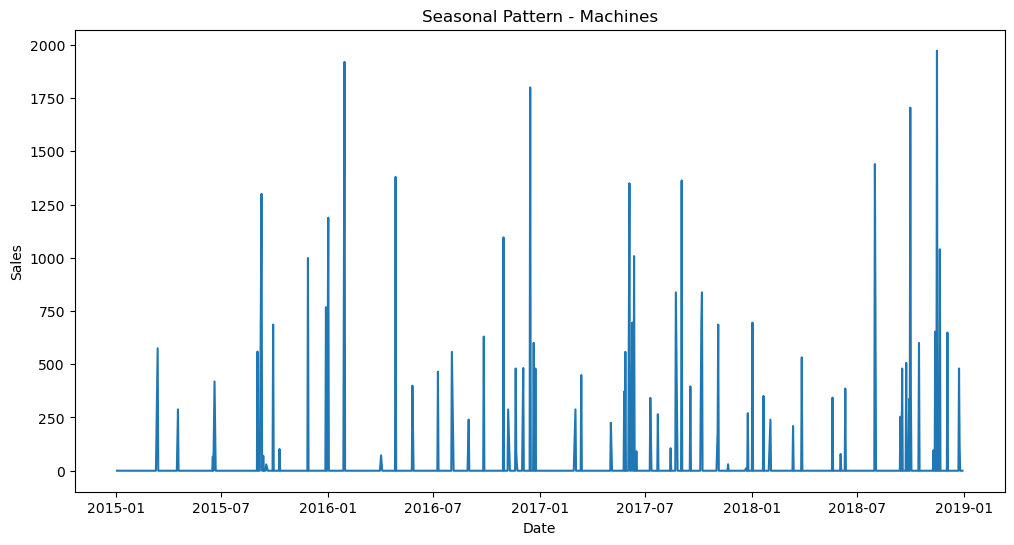

2025-06-03 11:22:34,705 - INFO - Processing file: ../data/processed/subcategories\subcategory_12.csv
2025-06-03 11:22:34,723 - INFO - Performing seasonal decomposition for Paper


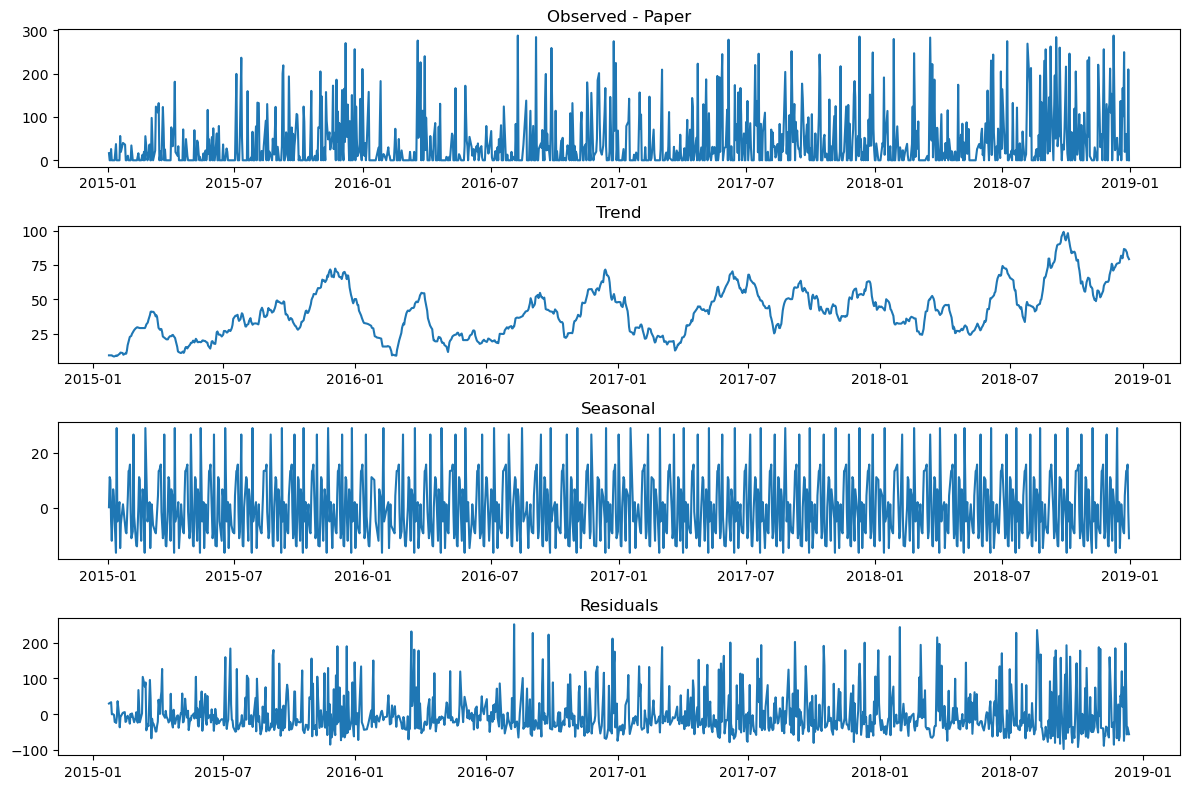

2025-06-03 11:22:42,406 - INFO - Performing ADF test for Paper
2025-06-03 11:22:42,638 - INFO - ADF Test for Paper: p-value = 0.0000
2025-06-03 11:22:42,645 - INFO - Performing KPSS test for Paper
C:\Users\sebas\AppData\Local\Temp\ipykernel_21060\869537997.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression="c")
2025-06-03 11:22:42,653 - INFO - KPSS Test for Paper: p-value = 0.0100


ADF Test for Paper: p-value = 0.0000
Result: Stationary (reject null hypothesis)
KPSS Test for Paper: p-value = 0.0100
Result: Non-stationary (reject null hypothesis)


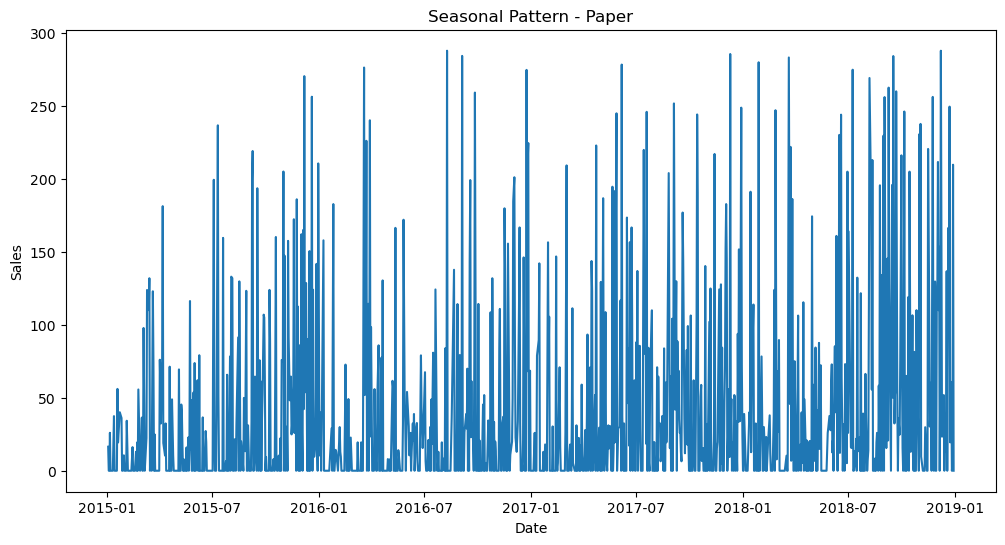

2025-06-03 11:22:45,086 - INFO - Processing file: ../data/processed/subcategories\subcategory_13.csv
2025-06-03 11:22:45,122 - INFO - Performing seasonal decomposition for Phones


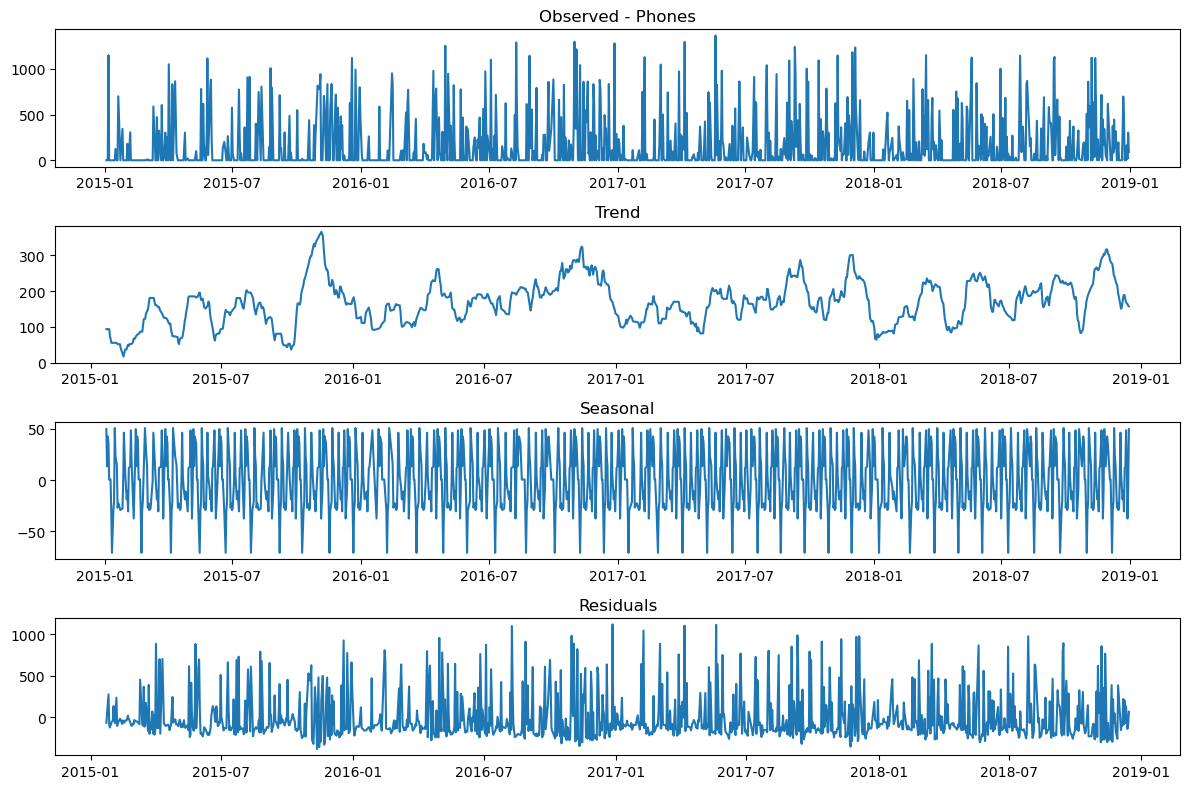

2025-06-03 11:22:52,347 - INFO - Performing ADF test for Phones
2025-06-03 11:22:52,647 - INFO - ADF Test for Phones: p-value = 0.0000
2025-06-03 11:22:52,650 - INFO - Performing KPSS test for Phones
2025-06-03 11:22:52,654 - INFO - KPSS Test for Phones: p-value = 0.0971


ADF Test for Phones: p-value = 0.0000
Result: Stationary (reject null hypothesis)
KPSS Test for Phones: p-value = 0.0971
Result: Stationary (fail to reject null hypothesis)


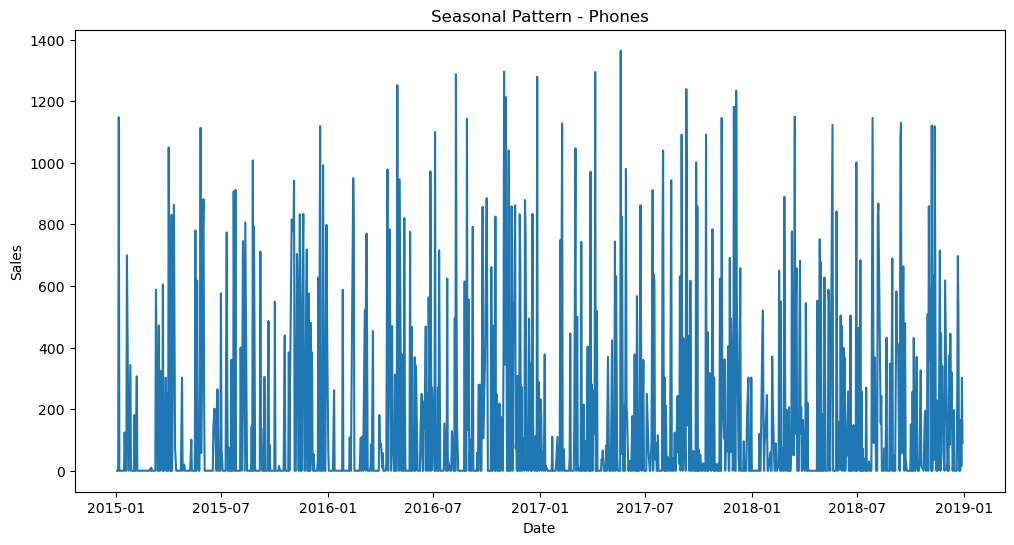

2025-06-03 11:22:54,579 - INFO - Processing file: ../data/processed/subcategories\subcategory_14.csv
2025-06-03 11:22:54,594 - INFO - Performing seasonal decomposition for Storage


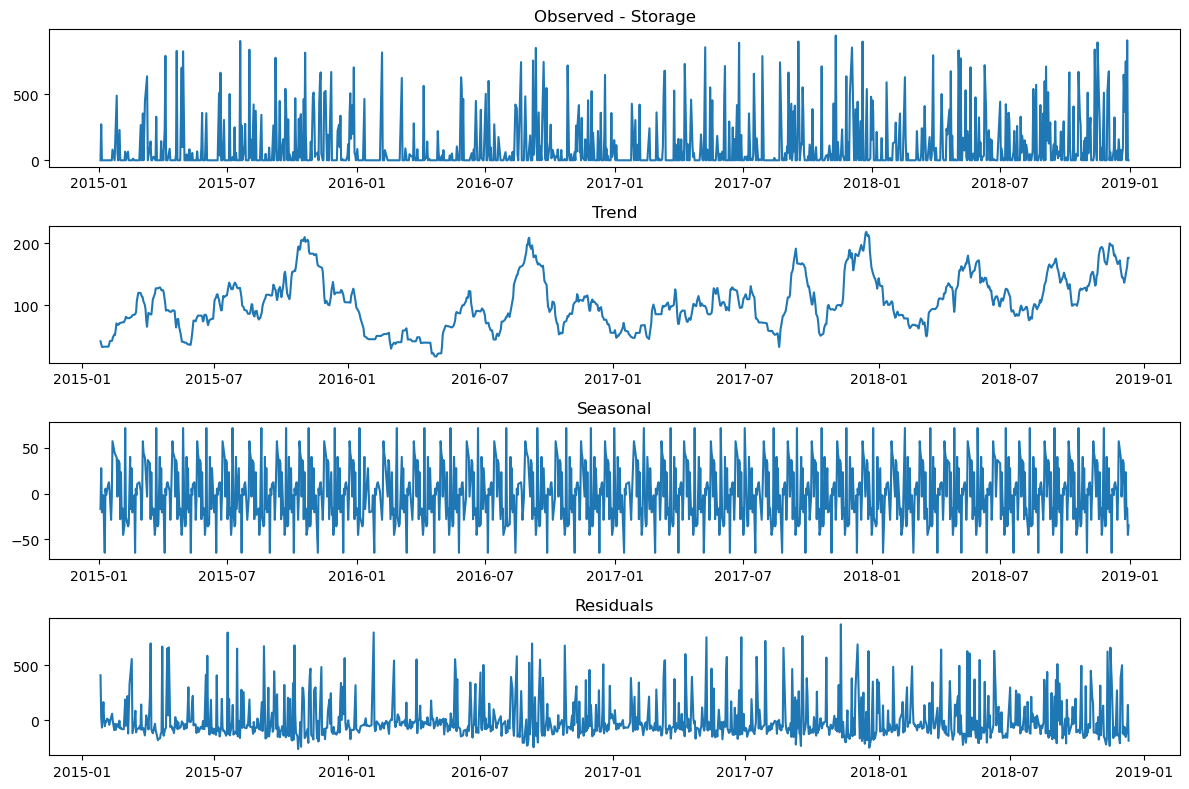

2025-06-03 11:23:01,881 - INFO - Performing ADF test for Storage
2025-06-03 11:23:02,086 - INFO - ADF Test for Storage: p-value = 0.0000
2025-06-03 11:23:02,094 - INFO - Performing KPSS test for Storage
C:\Users\sebas\AppData\Local\Temp\ipykernel_21060\869537997.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression="c")
2025-06-03 11:23:02,107 - INFO - KPSS Test for Storage: p-value = 0.0100


ADF Test for Storage: p-value = 0.0000
Result: Stationary (reject null hypothesis)
KPSS Test for Storage: p-value = 0.0100
Result: Non-stationary (reject null hypothesis)


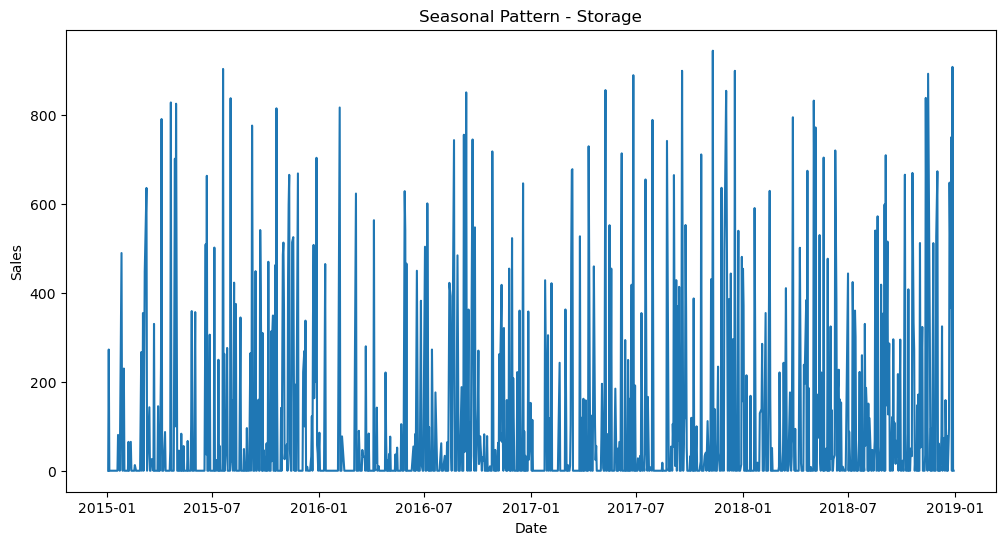

2025-06-03 11:23:04,006 - INFO - Processing file: ../data/processed/subcategories\subcategory_15.csv
2025-06-03 11:23:04,032 - INFO - Performing seasonal decomposition for Supplies


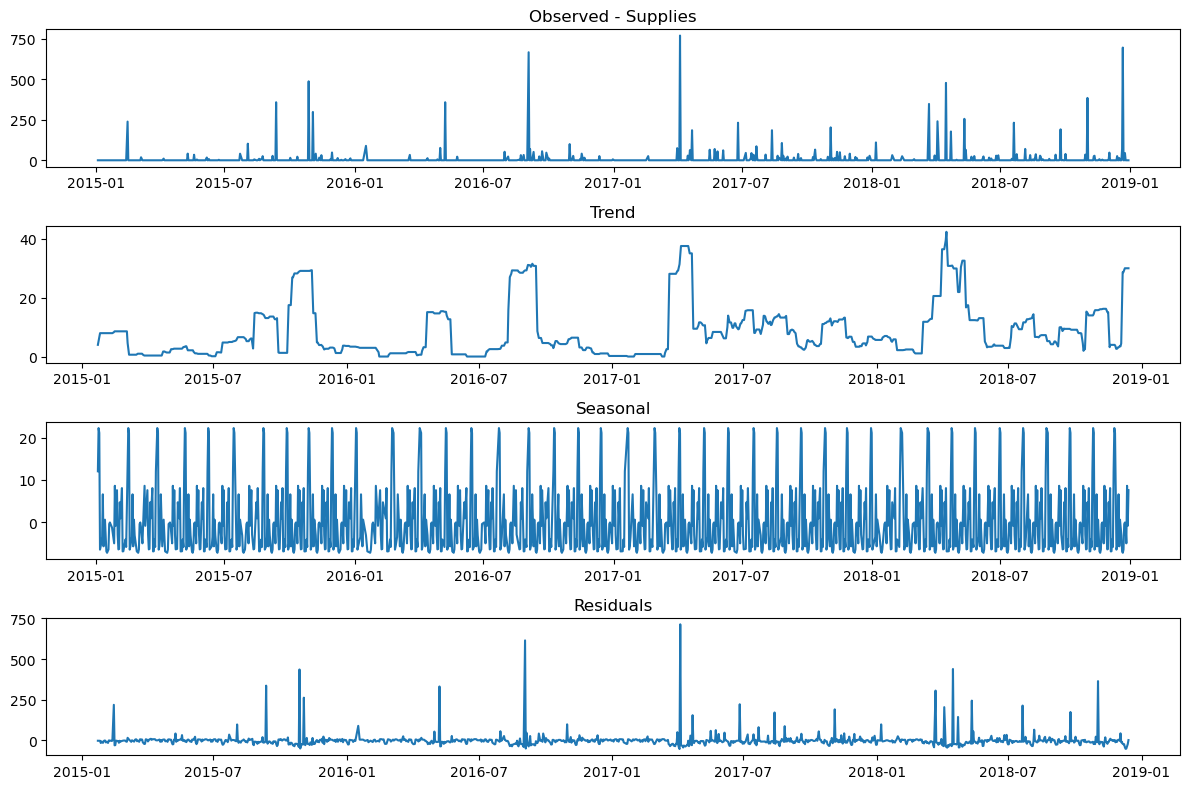

2025-06-03 11:23:11,901 - INFO - Performing ADF test for Supplies
2025-06-03 11:23:14,298 - INFO - ADF Test for Supplies: p-value = 0.0000
2025-06-03 11:23:14,309 - INFO - Performing KPSS test for Supplies
2025-06-03 11:23:14,313 - INFO - KPSS Test for Supplies: p-value = 0.0971


ADF Test for Supplies: p-value = 0.0000
Result: Stationary (reject null hypothesis)
KPSS Test for Supplies: p-value = 0.0971
Result: Stationary (fail to reject null hypothesis)


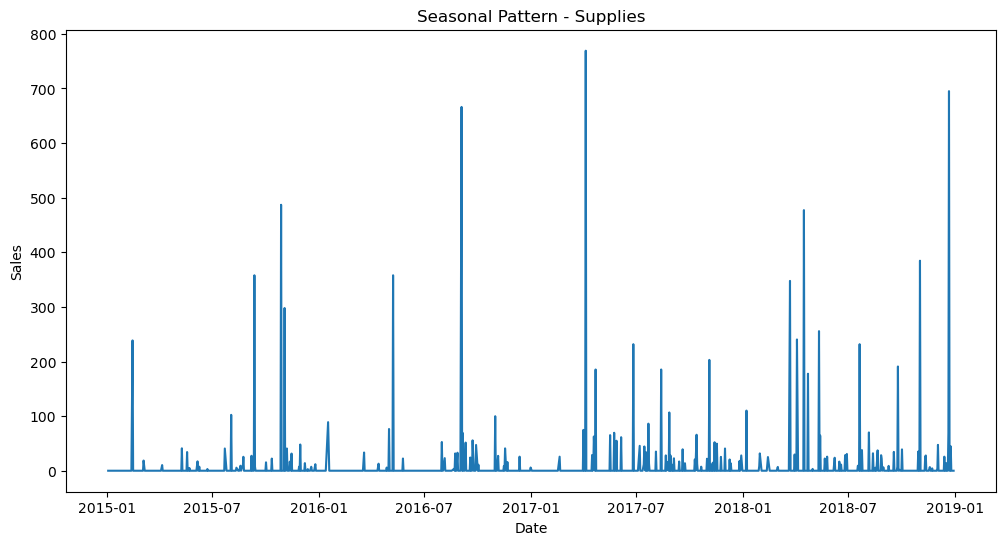

2025-06-03 11:23:16,565 - INFO - Processing file: ../data/processed/subcategories\subcategory_16.csv
2025-06-03 11:23:16,741 - INFO - Performing seasonal decomposition for Tables


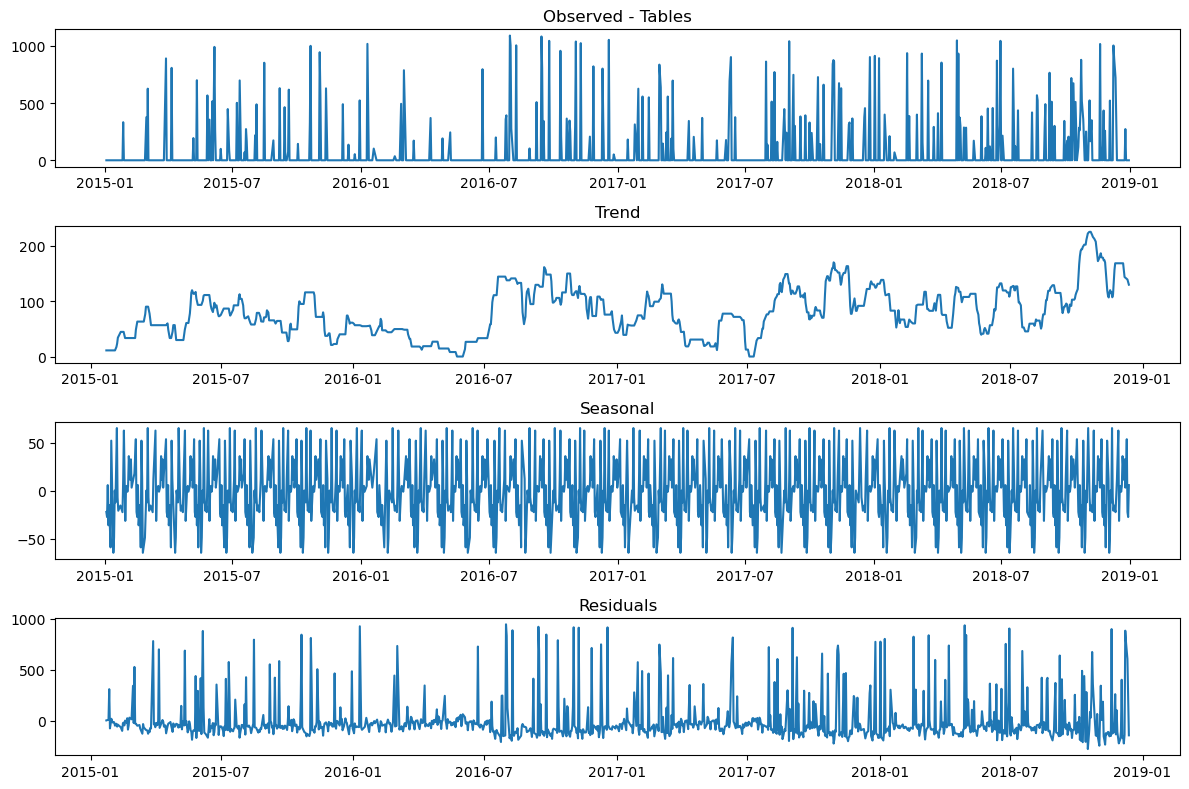

2025-06-03 11:23:23,663 - INFO - Performing ADF test for Tables
2025-06-03 11:23:24,762 - INFO - ADF Test for Tables: p-value = 0.0000
2025-06-03 11:23:24,765 - INFO - Performing KPSS test for Tables
C:\Users\sebas\AppData\Local\Temp\ipykernel_21060\869537997.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression="c")
2025-06-03 11:23:24,772 - INFO - KPSS Test for Tables: p-value = 0.0100


ADF Test for Tables: p-value = 0.0000
Result: Stationary (reject null hypothesis)
KPSS Test for Tables: p-value = 0.0100
Result: Non-stationary (reject null hypothesis)


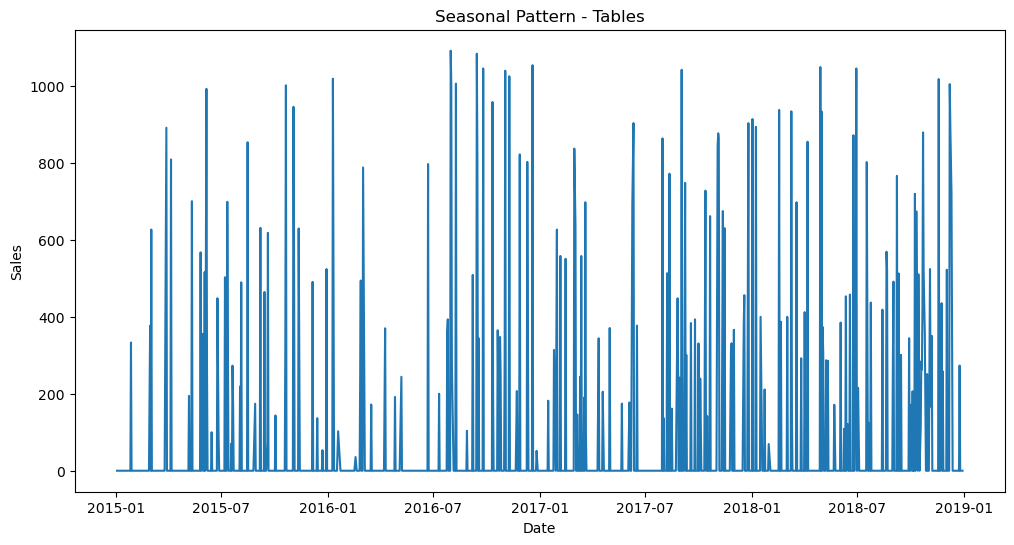

2025-06-03 11:23:27,948 - INFO - Processing file: ../data/processed/subcategories\subcategory_2.csv
2025-06-03 11:23:27,963 - INFO - Performing seasonal decomposition for Art


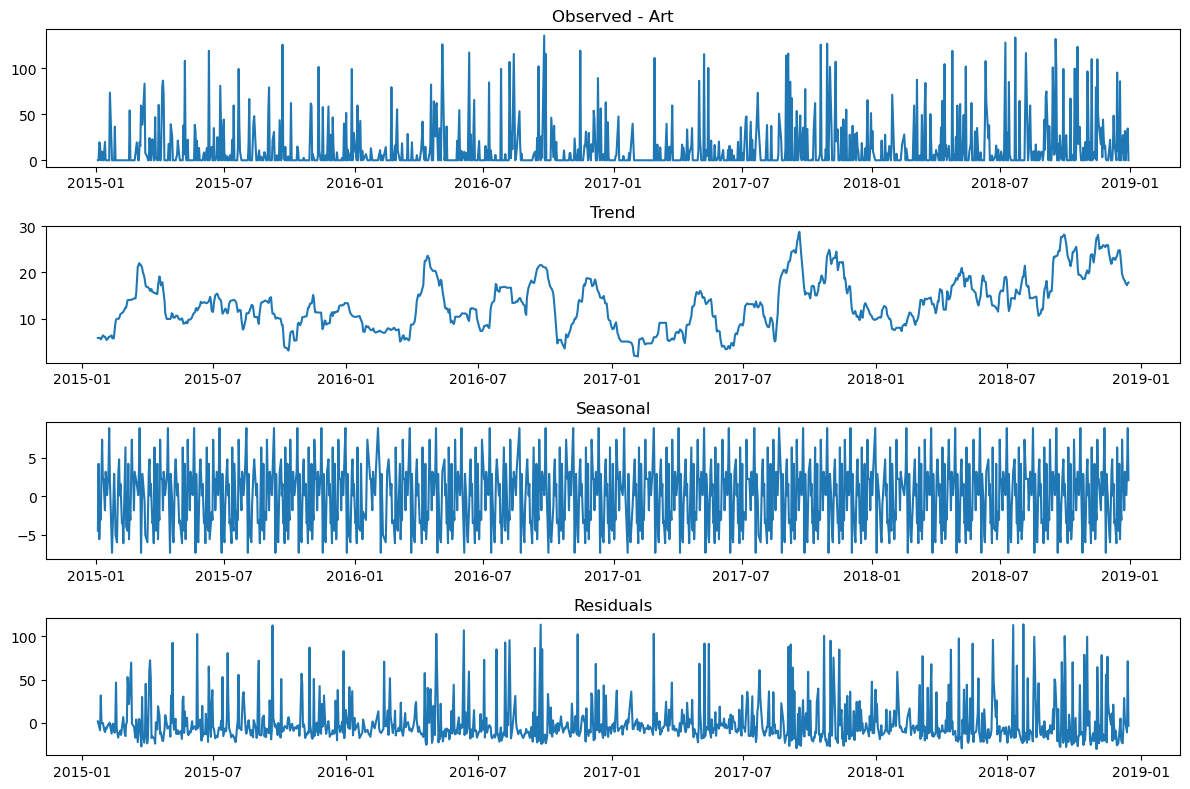

2025-06-03 11:23:33,280 - INFO - Performing ADF test for Art
2025-06-03 11:23:33,530 - INFO - ADF Test for Art: p-value = 0.0000
2025-06-03 11:23:33,543 - INFO - Performing KPSS test for Art
C:\Users\sebas\AppData\Local\Temp\ipykernel_21060\869537997.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression="c")
2025-06-03 11:23:33,558 - INFO - KPSS Test for Art: p-value = 0.0100


ADF Test for Art: p-value = 0.0000
Result: Stationary (reject null hypothesis)
KPSS Test for Art: p-value = 0.0100
Result: Non-stationary (reject null hypothesis)


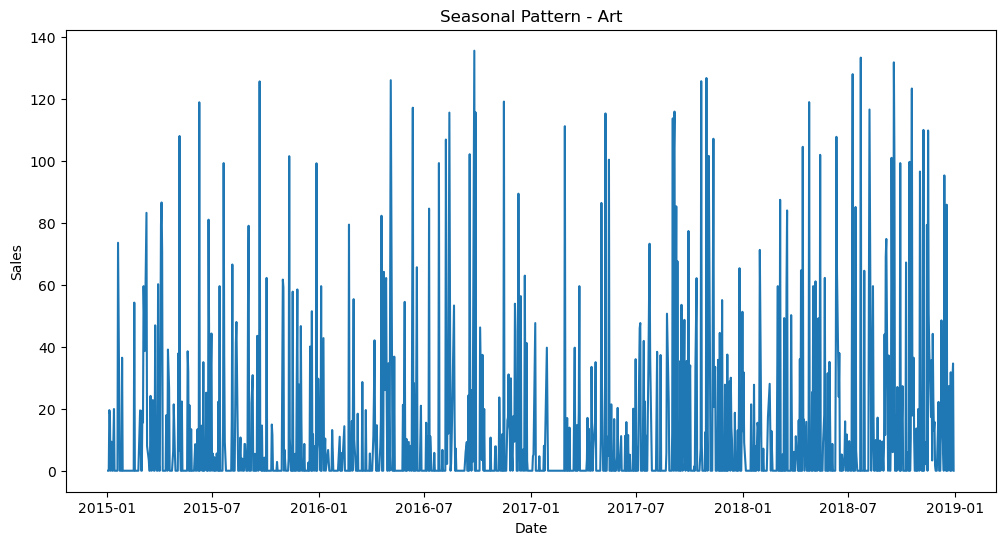

2025-06-03 11:23:35,492 - INFO - Processing file: ../data/processed/subcategories\subcategory_3.csv
2025-06-03 11:23:35,514 - INFO - Performing seasonal decomposition for Binders


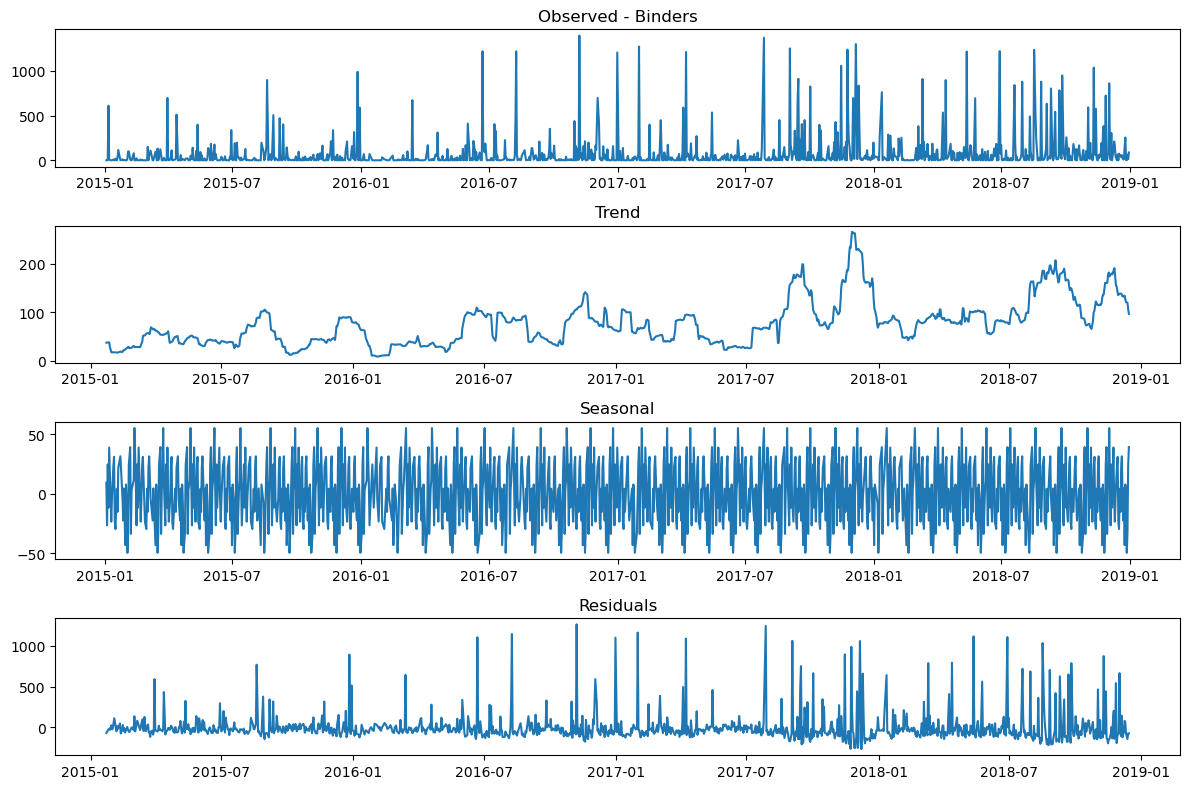

2025-06-03 11:23:45,520 - INFO - Performing ADF test for Binders
2025-06-03 11:23:45,877 - INFO - ADF Test for Binders: p-value = 0.0000
2025-06-03 11:23:45,888 - INFO - Performing KPSS test for Binders
C:\Users\sebas\AppData\Local\Temp\ipykernel_21060\869537997.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression="c")
2025-06-03 11:23:45,899 - INFO - KPSS Test for Binders: p-value = 0.0100


ADF Test for Binders: p-value = 0.0000
Result: Stationary (reject null hypothesis)
KPSS Test for Binders: p-value = 0.0100
Result: Non-stationary (reject null hypothesis)


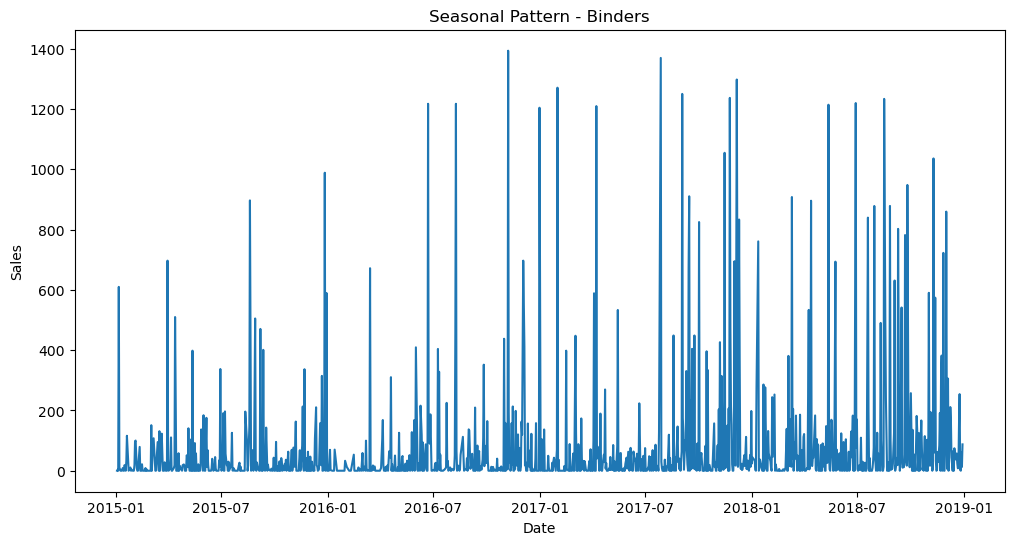

2025-06-03 11:23:48,985 - INFO - Processing file: ../data/processed/subcategories\subcategory_4.csv
2025-06-03 11:23:49,004 - INFO - Performing seasonal decomposition for Bookcases


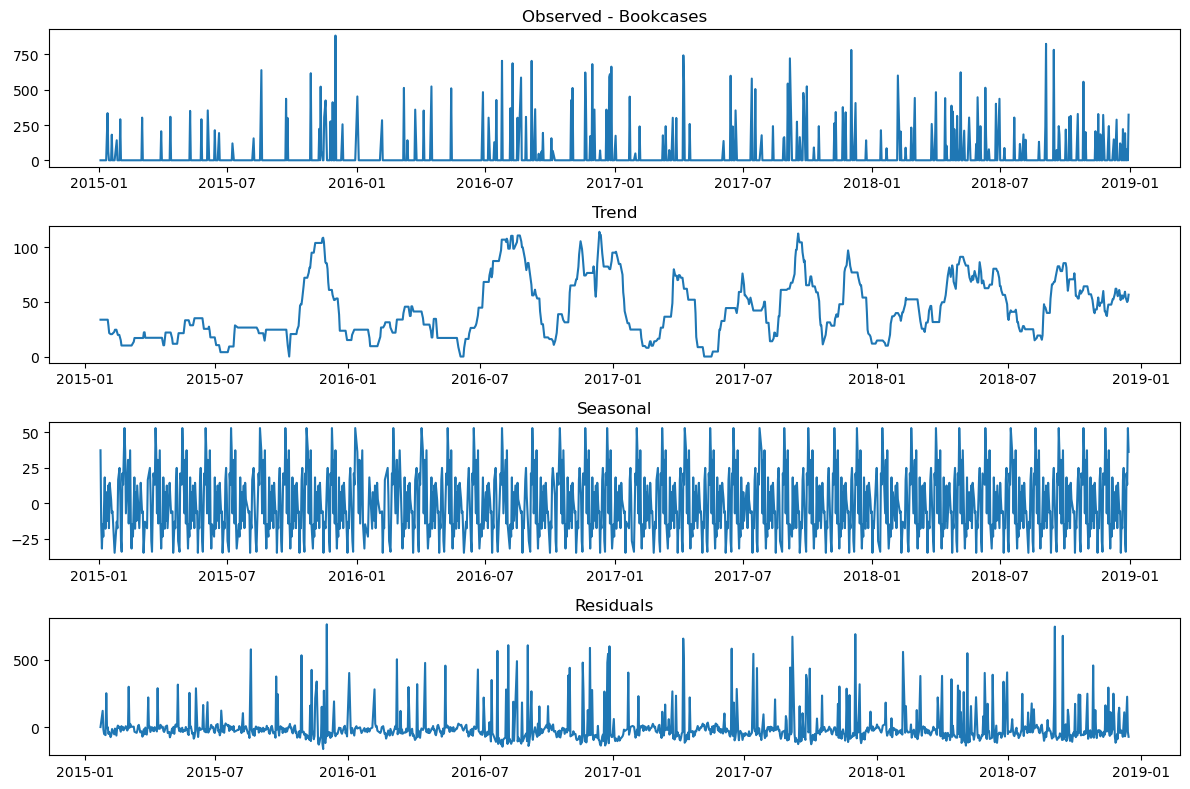

2025-06-03 11:23:57,371 - INFO - Performing ADF test for Bookcases
2025-06-03 11:23:57,654 - INFO - ADF Test for Bookcases: p-value = 0.0000
2025-06-03 11:23:57,657 - INFO - Performing KPSS test for Bookcases
2025-06-03 11:23:57,668 - INFO - KPSS Test for Bookcases: p-value = 0.0209


ADF Test for Bookcases: p-value = 0.0000
Result: Stationary (reject null hypothesis)
KPSS Test for Bookcases: p-value = 0.0209
Result: Non-stationary (reject null hypothesis)


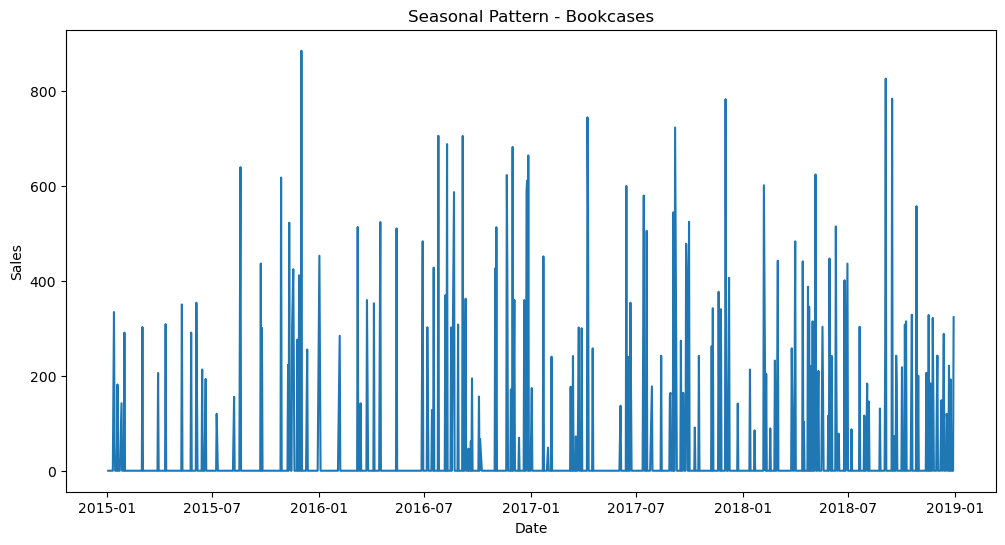

2025-06-03 11:24:01,166 - INFO - Processing file: ../data/processed/subcategories\subcategory_5.csv
2025-06-03 11:24:01,197 - INFO - Performing seasonal decomposition for Chairs


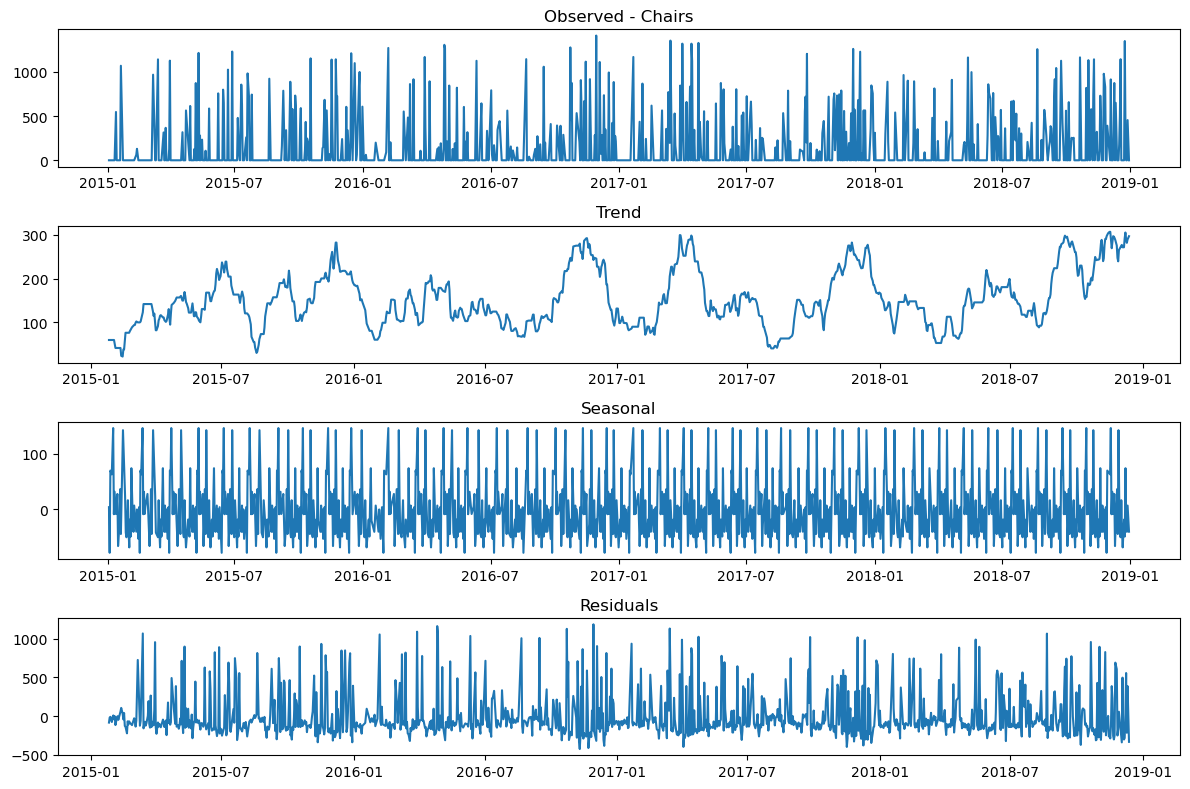

2025-06-03 11:24:07,790 - INFO - Performing ADF test for Chairs
2025-06-03 11:24:08,041 - INFO - ADF Test for Chairs: p-value = 0.0000
2025-06-03 11:24:08,055 - INFO - Performing KPSS test for Chairs
2025-06-03 11:24:08,064 - INFO - KPSS Test for Chairs: p-value = 0.0564


ADF Test for Chairs: p-value = 0.0000
Result: Stationary (reject null hypothesis)
KPSS Test for Chairs: p-value = 0.0564
Result: Stationary (fail to reject null hypothesis)


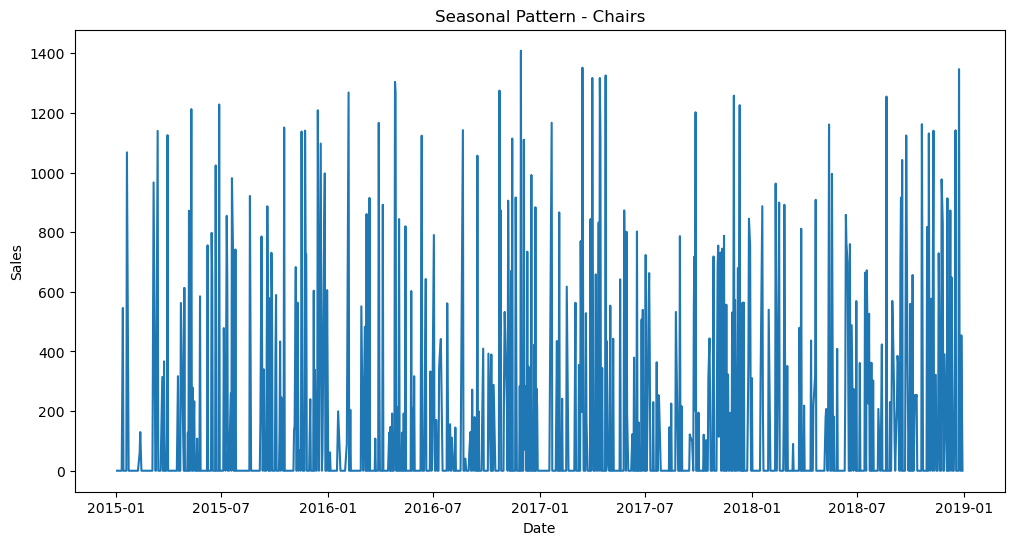

2025-06-03 11:24:11,848 - INFO - Processing file: ../data/processed/subcategories\subcategory_6.csv
2025-06-03 11:24:11,870 - INFO - Performing seasonal decomposition for Copiers


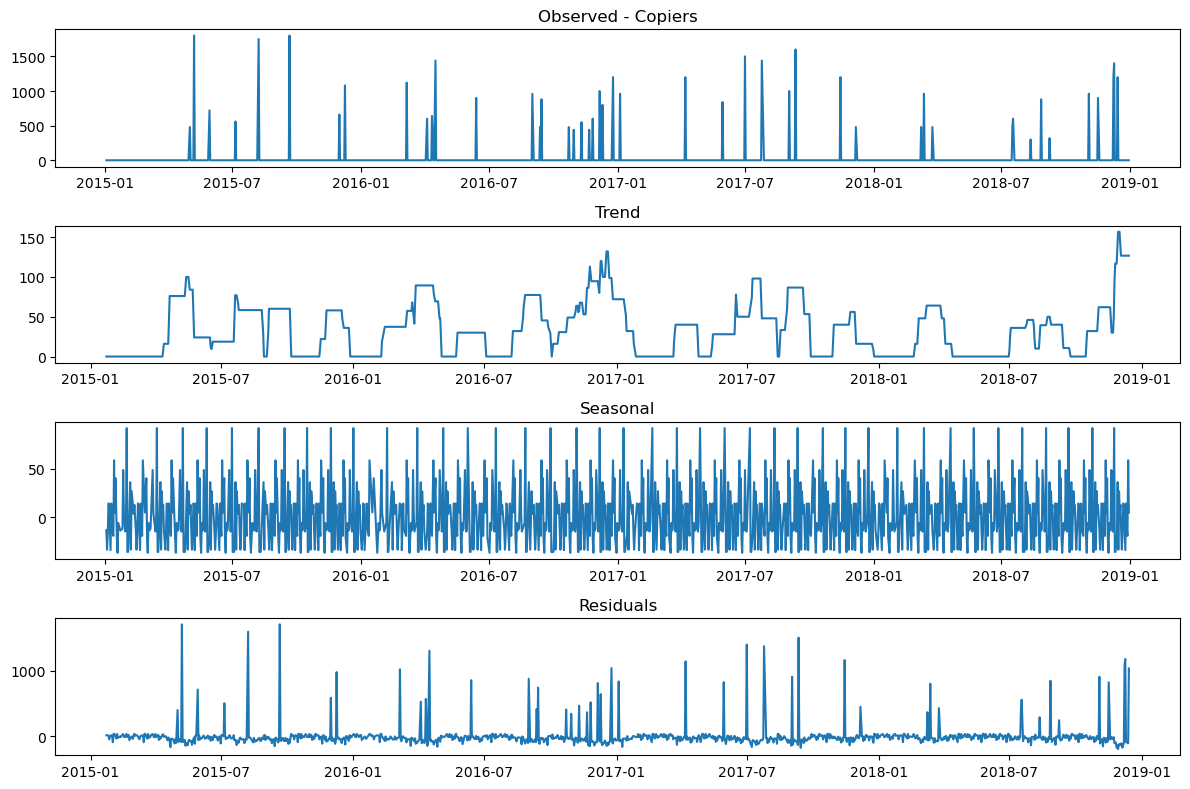

2025-06-03 11:24:18,204 - INFO - Performing ADF test for Copiers
2025-06-03 11:24:19,079 - INFO - ADF Test for Copiers: p-value = 0.0000
2025-06-03 11:24:19,082 - INFO - Performing KPSS test for Copiers
C:\Users\sebas\AppData\Local\Temp\ipykernel_21060\869537997.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression="c")
2025-06-03 11:24:19,098 - INFO - KPSS Test for Copiers: p-value = 0.1000


ADF Test for Copiers: p-value = 0.0000
Result: Stationary (reject null hypothesis)
KPSS Test for Copiers: p-value = 0.1000
Result: Stationary (fail to reject null hypothesis)


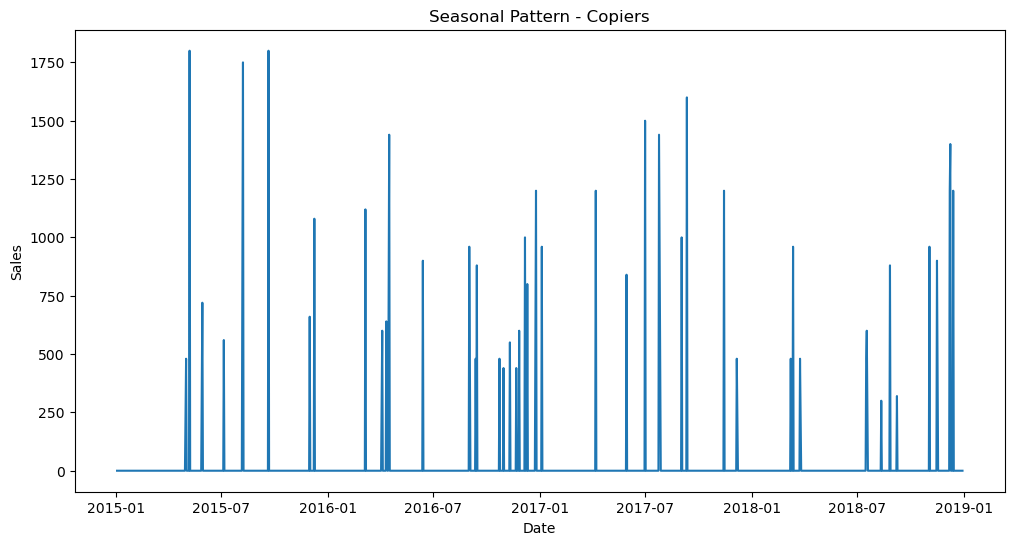

2025-06-03 11:24:22,729 - INFO - Processing file: ../data/processed/subcategories\subcategory_7.csv
2025-06-03 11:24:22,765 - INFO - Performing seasonal decomposition for Envelopes


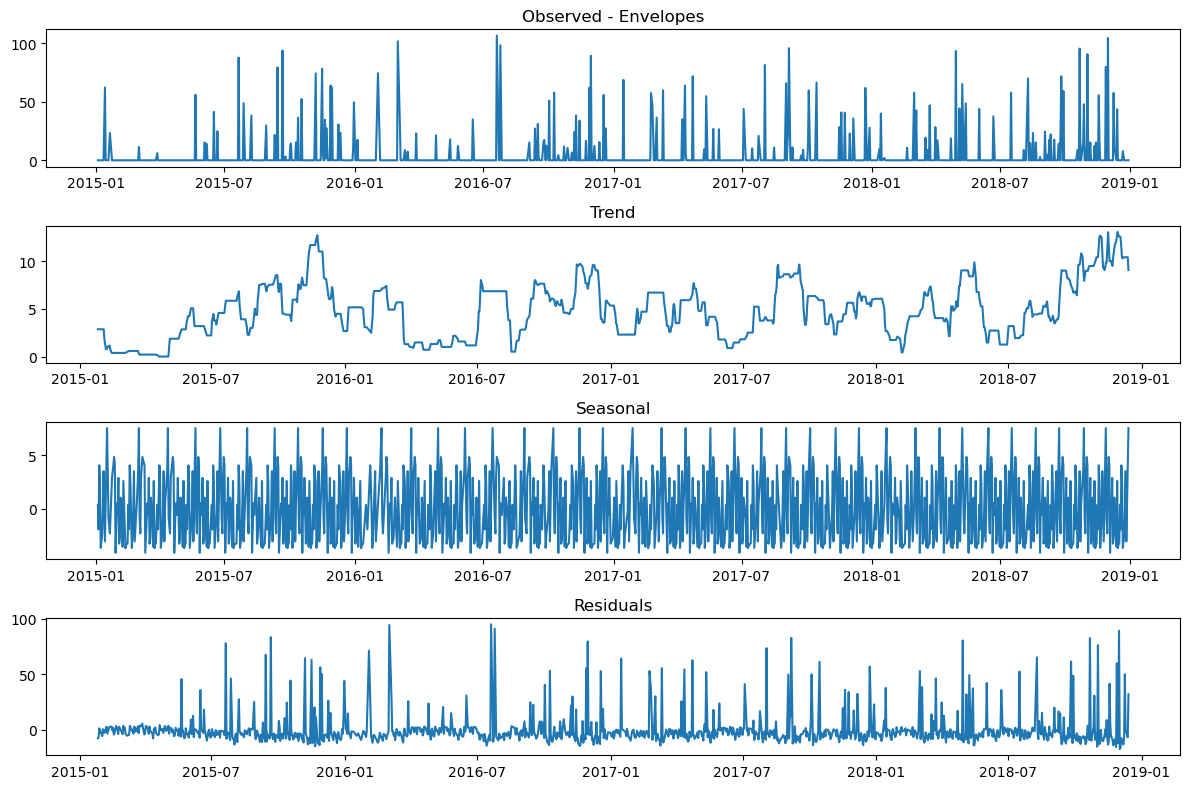

2025-06-03 11:24:30,198 - INFO - Performing ADF test for Envelopes
2025-06-03 11:24:30,468 - INFO - ADF Test for Envelopes: p-value = 0.0000
2025-06-03 11:24:30,477 - INFO - Performing KPSS test for Envelopes
2025-06-03 11:24:30,485 - INFO - KPSS Test for Envelopes: p-value = 0.0942


ADF Test for Envelopes: p-value = 0.0000
Result: Stationary (reject null hypothesis)
KPSS Test for Envelopes: p-value = 0.0942
Result: Stationary (fail to reject null hypothesis)


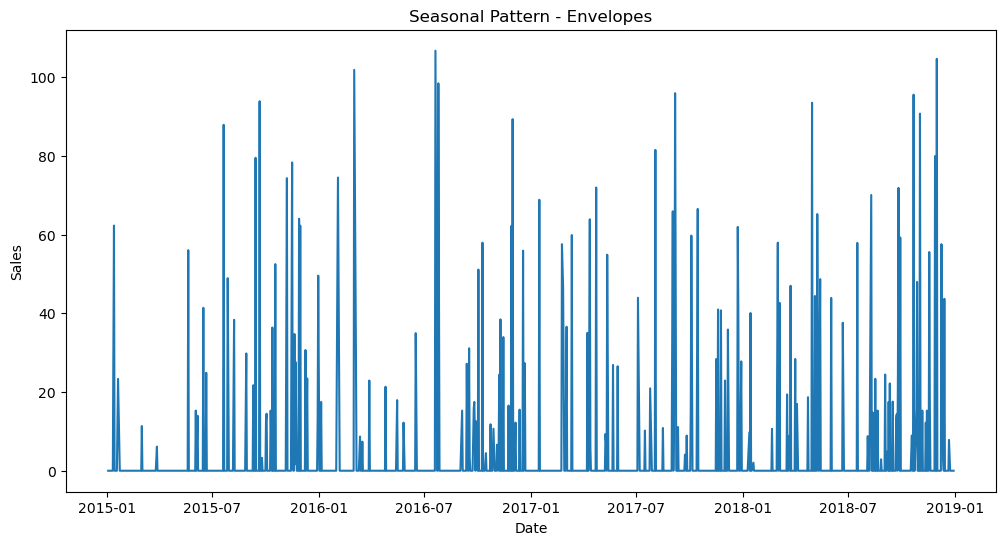

2025-06-03 11:24:33,062 - INFO - Processing file: ../data/processed/subcategories\subcategory_8.csv
2025-06-03 11:24:33,097 - INFO - Performing seasonal decomposition for Fasteners


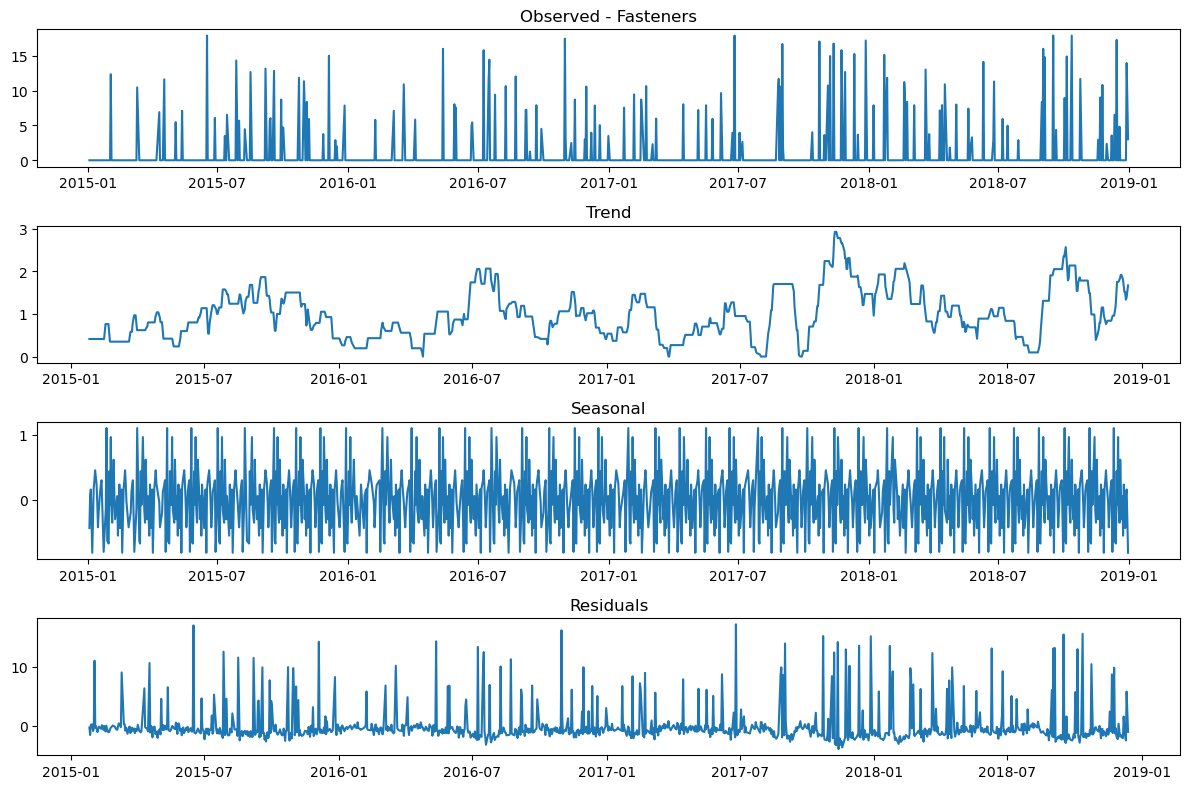

2025-06-03 11:24:41,518 - INFO - Performing ADF test for Fasteners
2025-06-03 11:24:41,833 - INFO - ADF Test for Fasteners: p-value = 0.0000
2025-06-03 11:24:41,838 - INFO - Performing KPSS test for Fasteners
2025-06-03 11:24:41,849 - INFO - KPSS Test for Fasteners: p-value = 0.0530


ADF Test for Fasteners: p-value = 0.0000
Result: Stationary (reject null hypothesis)
KPSS Test for Fasteners: p-value = 0.0530
Result: Stationary (fail to reject null hypothesis)


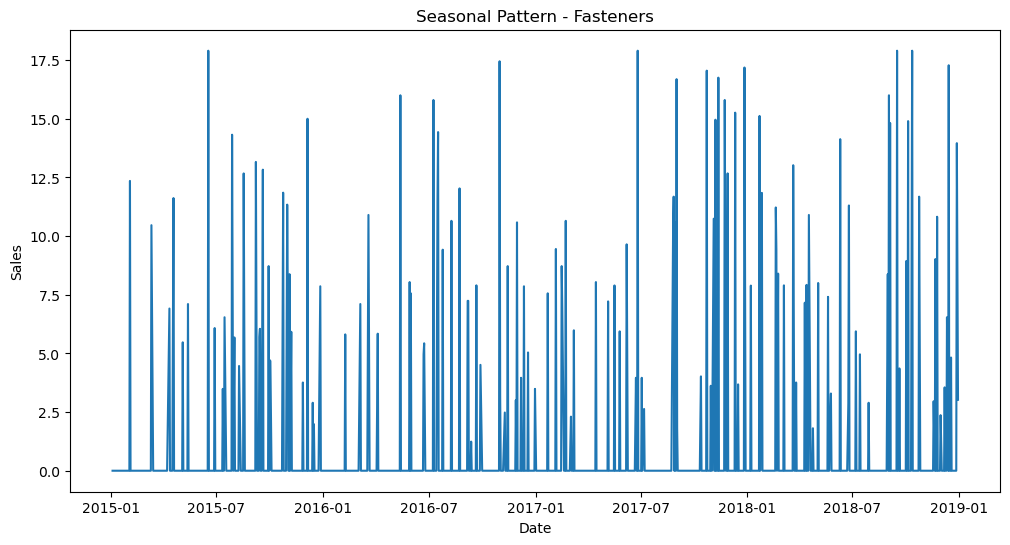

2025-06-03 11:24:44,383 - INFO - Processing file: ../data/processed/subcategories\subcategory_9.csv
2025-06-03 11:24:44,426 - INFO - Performing seasonal decomposition for Furnishings


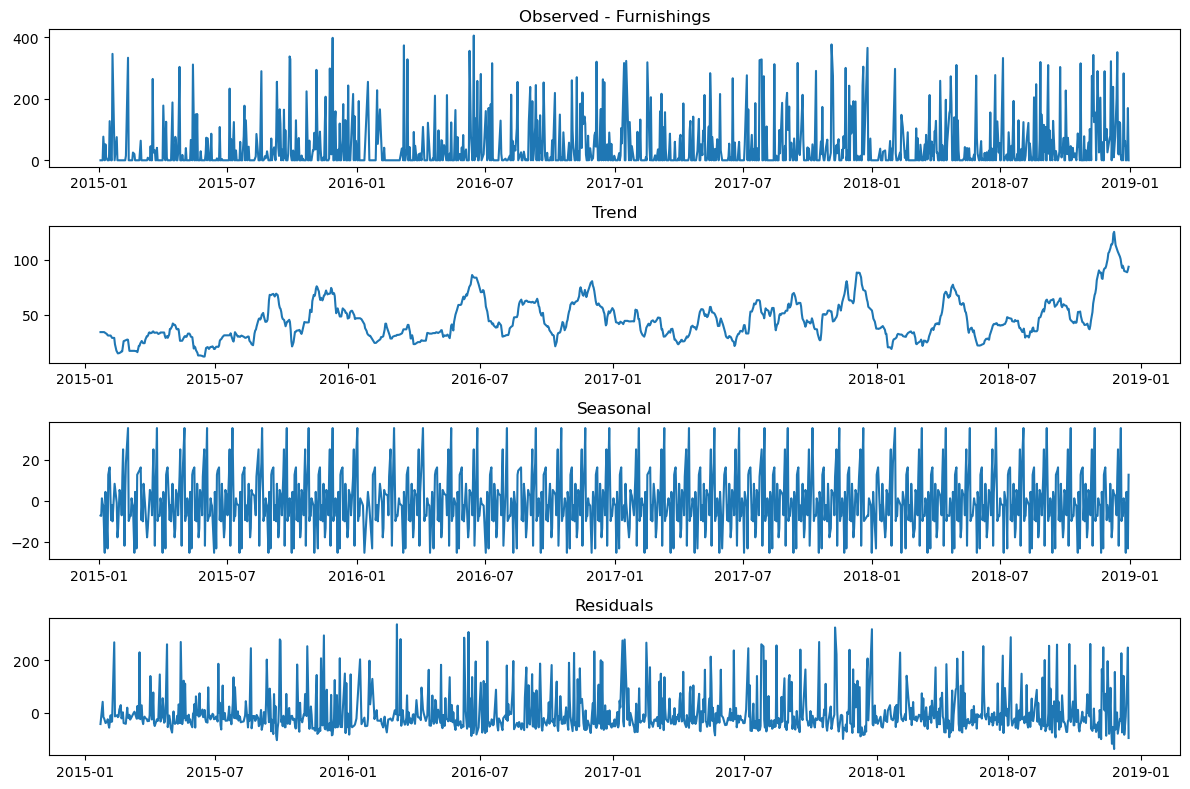

2025-06-03 11:24:51,472 - INFO - Performing ADF test for Furnishings
2025-06-03 11:24:51,732 - INFO - ADF Test for Furnishings: p-value = 0.0000
2025-06-03 11:24:51,737 - INFO - Performing KPSS test for Furnishings
C:\Users\sebas\AppData\Local\Temp\ipykernel_21060\869537997.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression="c")
2025-06-03 11:24:51,742 - INFO - KPSS Test for Furnishings: p-value = 0.0100


ADF Test for Furnishings: p-value = 0.0000
Result: Stationary (reject null hypothesis)
KPSS Test for Furnishings: p-value = 0.0100
Result: Non-stationary (reject null hypothesis)


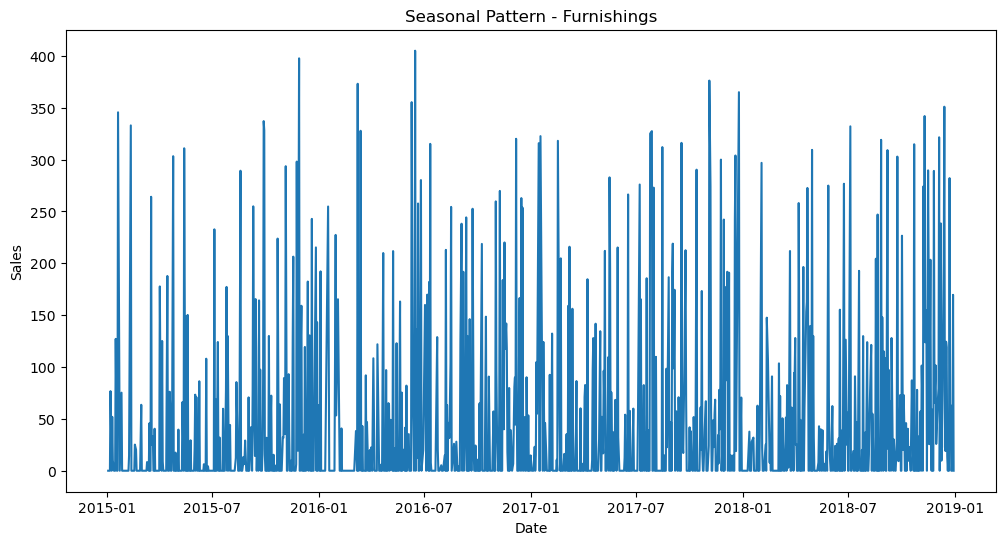

In [10]:
# Load and process all subcategory files
processed_dir = "../data/processed/subcategories"
subcategory_files = [f for f in os.listdir(processed_dir) if f.startswith("subcategory_") and f.endswith(".csv")]

for file in subcategory_files:
    file_path = os.path.join(processed_dir, file)
    subcategory_id = file.replace("subcategory_", "").replace(".csv", "")
    logger.info(f"Processing file: {file_path}")
    
    # Load data
    df = pd.read_csv(file_path, index_col=0, parse_dates=True)
    if df.index.name != 'order_date':
        df.index.name = 'order_date'
    series_name = df.columns[0] if len(df.columns) == 1 else f"subcategory_{subcategory_id}"
    series = df[series_name]
    
    # Seasonal decomposition (assuming monthly seasonality, adjust period as needed)
    logger.info(f"Performing seasonal decomposition for {series_name}")
    decomposition = seasonal_decompose(series, model='additive', period=30)  # 30 days as a rough seasonal period
    plot_seasonal_decomposition(decomposition, series_name)
    
    # Stationarity tests
    logger.info(f"Performing ADF test for {series_name}")
    perform_adf_test(series, series_name)
    logger.info(f"Performing KPSS test for {series_name}")
    perform_kpss_test(series, series_name)
    
    # Visualize seasonal patterns
    plt.figure(figsize=(12, 6))
    plt.plot(series)
    plt.title(f"Seasonal Pattern - {series_name}")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.savefig(os.path.join(output_dir, f"seasonal_pattern_{series_name}.png"))
    plt.show()
    plt.close()